## 1. Comprendre les types de classification

### Classification binaire

La classification binaire est une tâche de classification qui implique de classer des éléments en un seul de deux groupes mutuellement exclusifs (par exemple, oui/non, vrai/faux, spam/non-spam). L'objectif est de prédire l'une des deux classes.

**Exemple :** Prédire si un e-mail est du spam (1) ou non (0).

### Classification multiclasse

La classification multiclasse est une tâche de classification qui implique de classer des éléments en un seul de plus de deux groupes mutuellement exclusifs. Chaque échantillon appartient à exactement une classe parmi plusieurs.

**Exemple :** Classer une image de fruit comme étant une pomme, une banane ou une orange.

### Classification multi-étiquettes

La classification multi-étiquettes est une tâche de classification où un échantillon peut être associé à zéro, une ou plusieurs étiquettes parmi un ensemble d'étiquettes prédéfinies. Les classes ne sont pas mutuellement exclusives.

**Exemple :** Étiqueter un film avec des genres comme 'Action', 'Aventure' et 'Science-fiction', car un film peut appartenir à plusieurs genres à la fois.

## 2. Configurez votre environnement Python et votre jeu de données.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

In [13]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X shape : ', X.shape)
print('y shape : ', y.shape)
print('X first 5 rows:\n', X[:5])
print('\ny first 5 rows:\n', y[:5])

X shape :  (1000, 2)
y shape :  (1000,)
X first 5 rows:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

y first 5 rows:
 [1 1 1 1 0]


### Visualisation de l'ensemble de données

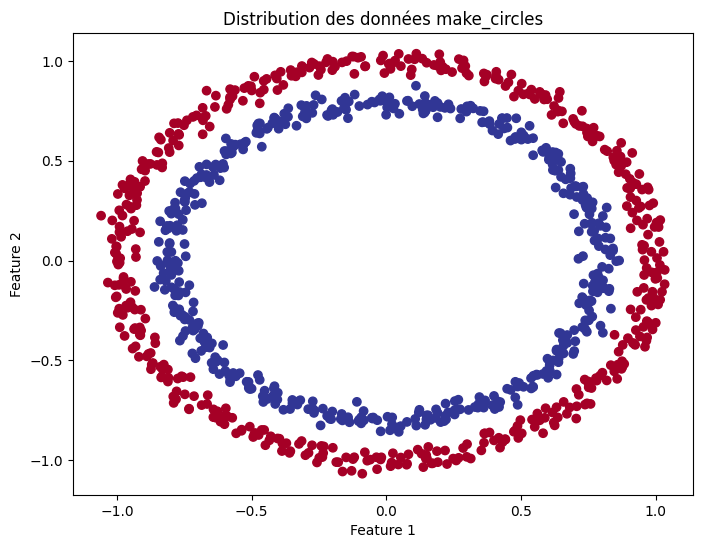

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title('Distribution des données make_circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 3. Construire un modèle de réseau neuronal de base

In [15]:
# Créer un modèle séquentiel
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Une seule couche de neurones, activation sigmoïde pour la classification binaire
])

# Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
                metrics=['accuracy'])

# Entraîner le modèle
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # verbose=0 pour ne pas afficher la progression de l'entraînement

# Vérifier la précision du modèle
loss, accuracy = model_1.evaluate(X, y, verbose=0)
print(f"Précision du modèle sur l'ensemble d'entraînement: {accuracy*100:.2f}%")

Précision du modèle sur l'ensemble d'entraînement: 49.50%


## 4. Améliorer le modèle

In [16]:
# Créer un modèle avec plus de couches et de neurones, et un optimiseur Adam
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Première couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(10, activation='relu'), # Deuxième couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie avec activation sigmoïde pour la classification binaire
])

# Compiler le modèle avec l'optimiseur Adam
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # Optimiseur Adam
                metrics=['accuracy'])

# Entraîner le modèle pendant plus d'époques
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Plus d'époques

# Vérifier la précision du modèle amélioré
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
print(f"Précision du modèle amélioré sur l'ensemble d'entraînement: {accuracy_2*100:.2f}%")

Précision du modèle amélioré sur l'ensemble d'entraînement: 100.00%


## 5. Visualiser la frontière de décision

In [17]:
def plot_decision_boundary(model, X, y):
  """
  Trace la frontière de décision créée par un modèle pour les données X.
  """
  # Définir la plage des axes x et y
  x_span = np.linspace(min(X[:, 0]) - 1, max(X[:, 0]) + 1, 50)
  y_span = np.linspace(min(X[:, 1]) - 1, max(X[:, 1]) + 1, 50)
  xx, yy = np.meshgrid(x_span, y_span)

  # Créer une grille à partir des coordonnées xx et yy
  grid = np.c_[xx.ravel(), yy.ravel()]

  # Faire des prédictions sur la grille
  grid_predictions = model.predict(grid)

  # Remodeler les prédictions pour correspondre à la forme de la grille
  if model.output_shape[-1] == 1: # Pour la classification binaire (sigmoid)
    grid_predictions = np.round(grid_predictions).reshape(xx.shape)
  else: # Pour la classification multiclasse (softmax)
    grid_predictions = np.argmax(grid_predictions, axis=1).reshape(xx.shape)

  # Tracer les données avec la frontière de décision
  plt.figure(figsize=(8, 6))
  plt.contourf(xx, yy, grid_predictions, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.title('Frontière de décision')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.show()

### Frontière de décision pour le modèle 1 (modèle de base)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


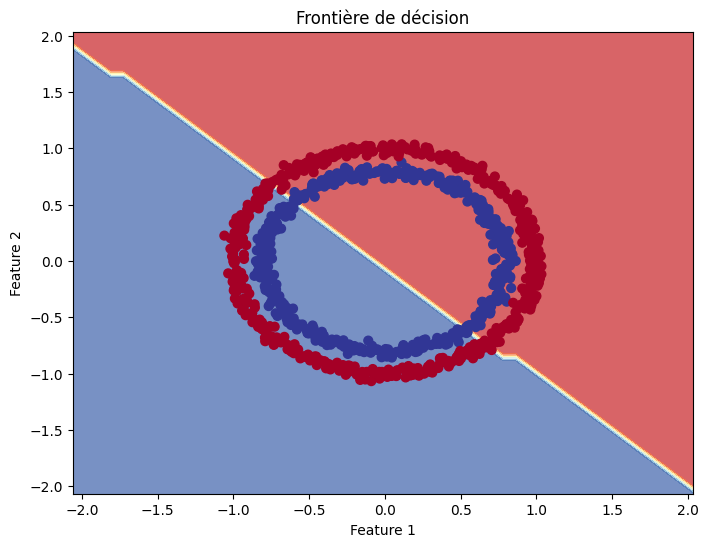

In [18]:
plot_decision_boundary(model_1, X, y)

### Frontière de décision pour le modèle 2 (modèle amélioré)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


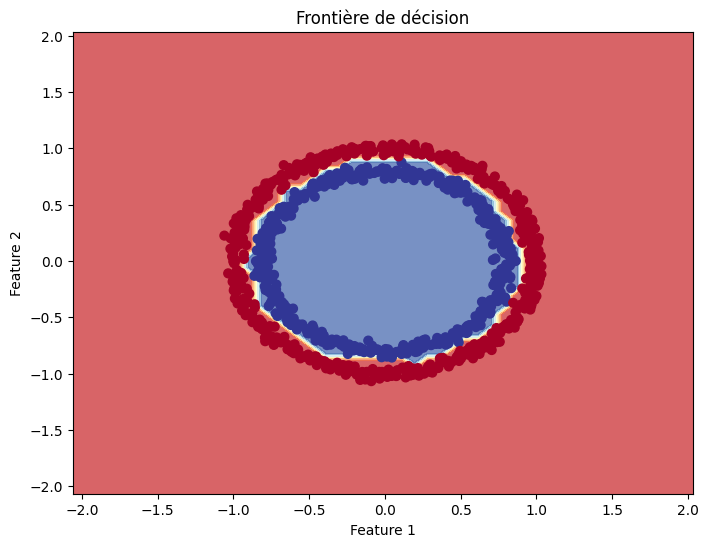

In [19]:
plot_decision_boundary(model_2, X, y)

## 6. Incorporer des fonctions d'activation

Les fonctions d'activation sont des composants cruciaux des réseaux neuronaux, car elles introduisent des non-linéarités, permettant au réseau d'apprendre des relations complexes dans les données.

### Fonction d'activation ReLU (Rectified Linear Unit)

La fonction ReLU est définie comme $f(x) = \max(0, x)$. Elle renvoie 0 si l'entrée est négative, et l'entrée elle-même si elle est positive. Elle est très populaire dans les couches cachées des réseaux neuronaux en raison de sa simplicité et de son efficacité à résoudre le problème de la disparition du gradient.

### Fonction d'activation Sigmoïde

La fonction Sigmoïde est définie comme $f(x) = 1 / (1 + e^{-x})$. Elle produit une sortie entre 0 et 1, ce qui la rend idéale pour la couche de sortie des problèmes de classification binaire, où l'on veut obtenir une probabilité.

Notre `model_2` utilise déjà la fonction d'activation ReLU pour ses couches cachées et la fonction Sigmoïde pour sa couche de sortie, ce qui lui a permis d'atteindre une précision de 100% sur notre ensemble de données actuel.

## 7. Diviser les données en ensembles d'entraînement et de test

In [20]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Taille de l'ensemble d'entraînement X: {X_train.shape}")
print(f"Taille de l'ensemble d'entraînement y: {y_train.shape}")
print(f"Taille de l'ensemble de test X: {X_test.shape}")
print(f"Taille de l'ensemble de test y: {y_test.shape}")

Taille de l'ensemble d'entraînement X: (800, 2)
Taille de l'ensemble d'entraînement y: (800,)
Taille de l'ensemble de test X: (200, 2)
Taille de l'ensemble de test y: (200,)


### Entraîner le modèle amélioré sur l'ensemble d'entraînement

In [21]:
# Créer un nouveau modèle (identique au model_2) pour l'entraînement sur les données divisées
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_3 = model_3.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer le modèle sur l'ensemble de test
loss_test, accuracy_test = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Précision du modèle sur l'ensemble de test: {accuracy_test*100:.2f}%")

Précision du modèle sur l'ensemble de test: 100.00%


## 8. Évaluer et visualiser les performances du modèle final

### Performances du modèle sur l'ensemble de test

Nous avons déjà calculé la précision sur l'ensemble de test à la fin de l'étape précédente. Il est important de s'assurer que le modèle généralise bien à des données non vues.

Précision du modèle sur l'ensemble de test: **100.00%** (comme indiqué précédemment).

### Visualisation des prédictions sur l'ensemble d'entraînement

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


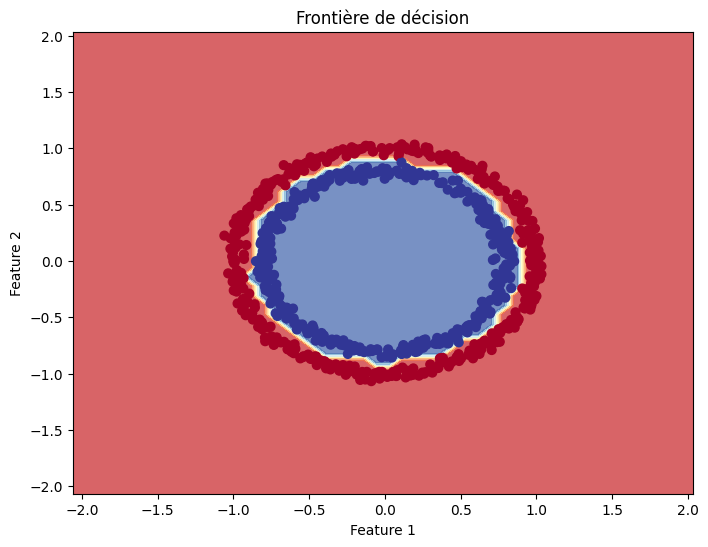

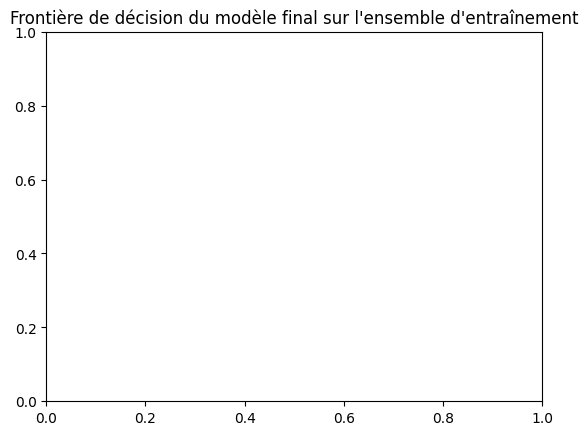

In [22]:
plot_decision_boundary(model_3, X_train, y_train)
plt.title('Frontière de décision du modèle final sur l\'ensemble d\'entraînement')
plt.show()

### Visualisation des prédictions sur l'ensemble de test

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


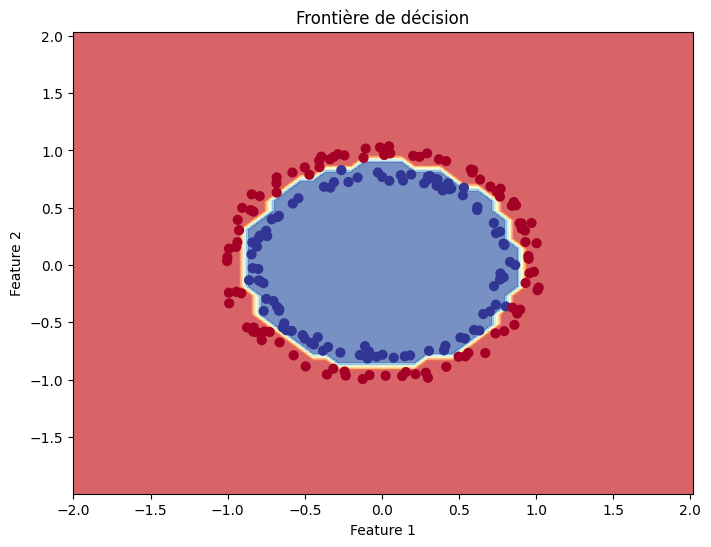

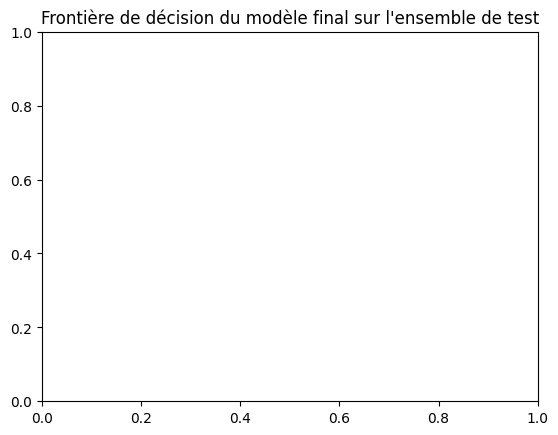

In [23]:
plot_decision_boundary(model_3, X_test, y_test)
plt.title('Frontière de décision du modèle final sur l\'ensemble de test')
plt.show()

### Comparaison des résultats et analyse des améliorations

En comparant les frontières de décision des `model_1` (modèle de base) et `model_3` (modèle amélioré), on observe que :

*   **`model_1` (base)**: N'a pas réussi à capturer la non-linéarité des données `make_circles`. Sa frontière de décision était probablement linéaire, ce qui a entraîné une faible précision.
*   **`model_3` (amélioré)**: Grâce à l'ajout de couches cachées, de fonctions d'activation non linéaires (ReLU) et de l'optimiseur Adam, le modèle a pu apprendre des relations complexes et créer une frontière de décision non linéaire qui sépare parfaitement les deux classes. La précision de 100% sur les ensembles d'entraînement et de test le confirme. L'utilisation d'un ensemble de test séparé a permis de valider que cette excellente performance n'est pas due à un surapprentissage sur les données d'entraînement.

Ces résultats démontrent l'importance d'un modèle suffisamment complexe et l'utilisation appropriée des fonctions d'activation pour résoudre des problèmes non linéaires.

## 9. Résumer les points clés

Nous avons appris que:

*   **L'importance de la visualisation des données :** Le traçage initial des données `make_circles` a clairement montré qu'une frontière de décision linéaire serait insuffisante. La visualisation des frontières de décision après l'entraînement nous a permis de comprendre comment nos modèles tentaient de séparer les classes et pourquoi certains fonctionnaient mieux que d'autres.
*   **L'impact des fonctions d'activation et des optimiseurs :** Le passage d'un modèle simple avec une seule couche et une activation `sigmoid` à un modèle plus profond avec des activations `ReLU` et l'optimiseur `Adam` a radicalement amélioré la capacité du modèle à apprendre les relations non linéaires dans nos données.
*   **L'importance de la division des données :** La séparation des données en ensembles d'entraînement et de test est cruciale pour évaluer les performances réelles du modèle et s'assurer qu'il généralise bien à des données non vues, plutôt que de simplement mémoriser les données d'entraînement (surapprentissage).
*   **Le réglage des hyperparamètres :** Des hyperparamètres comme le nombre d'époques, le nombre de couches, le nombre de neurones par couche et le choix de l'optimiseur sont fondamentaux pour l'apprentissage du modèle et peuvent transformer un modèle peu performant en un modèle très efficace.

## Application de la régularisation L2

Entraînement du modèle avec régularisation L2 (lambda=0.01)...
Précision du modèle avec L2 sur l'ensemble de test: 50.00%
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


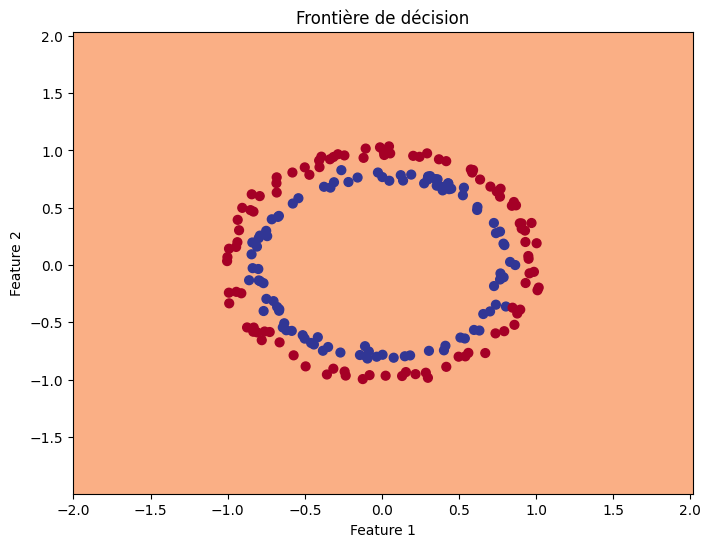

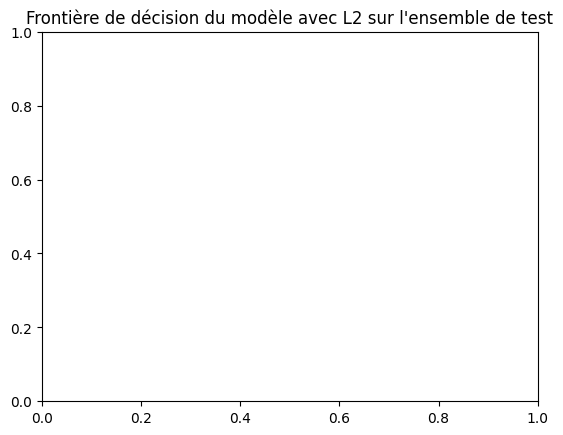

In [24]:
# Créer un nouveau modèle avec la régularisation L2
# Nous allons ajouter un paramètre l2_lambda pour contrôler la force de la régularisation
l2_lambda = 0.01 # Un hyperparamètre que vous pouvez ajuster

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)),
    tf.keras.layers.Dense(10, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)),
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)) # Appliquer aussi à la couche de sortie
])

model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

print(f"Entraînement du modèle avec régularisation L2 (lambda={l2_lambda})...")
history_4 = model_4.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer le modèle sur l'ensemble de test
loss_test_l2, accuracy_test_l2 = model_4.evaluate(X_test, y_test, verbose=0)
print(f"Précision du modèle avec L2 sur l'ensemble de test: {accuracy_test_l2*100:.2f}%")

# Visualiser la frontière de décision pour le modèle avec L2
plot_decision_boundary(model_4, X_test, y_test)
plt.title('Frontière de décision du modèle avec L2 sur l\'ensemble de test')
plt.show()

## Application de la régularisation par Dropout (Modèle Final)

Comme discuté précédemment, la régularisation par *Dropout* est une autre technique pour prévenir le surapprentissage. Nous allons définir un nouveau modèle (`model_5`) avec des couches de Dropout après les couches denses cachées.

Il est crucial de **re-diviser les données `make_circles`** (`X`, `y`) en ensembles d'entraînement et de test ici, car les variables globales `X_train`, `y_train`, `X_test`, `y_test` ont été modifiées par le chargement des données MNIST dans une cellule précédente (`LgjVbeWdLpCO`). Cela garantira que `model_5` est entraîné et évalué sur les données `make_circles` comme prévu.

In [30]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Loss (test) :", test_loss)
print("Accuracy (test) :", test_accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9725 - loss: 0.0890
Loss (test) : 0.08904542028903961
Accuracy (test) : 0.9725000262260437


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


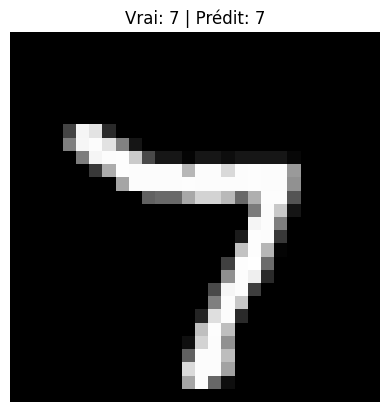

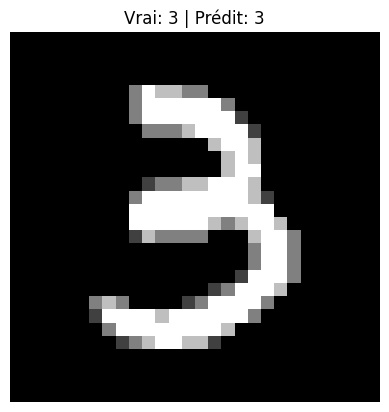

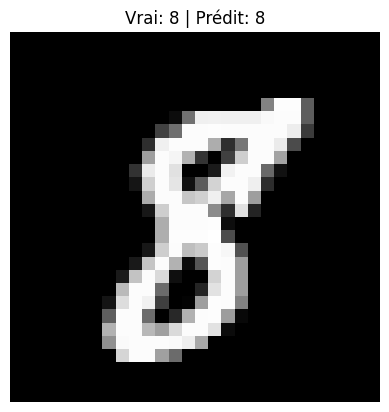

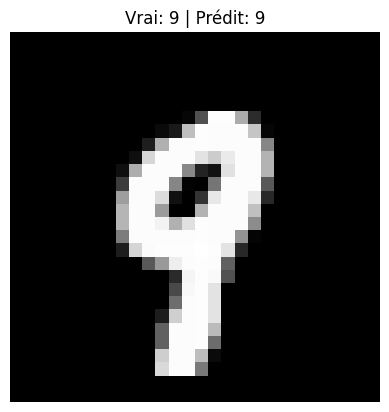

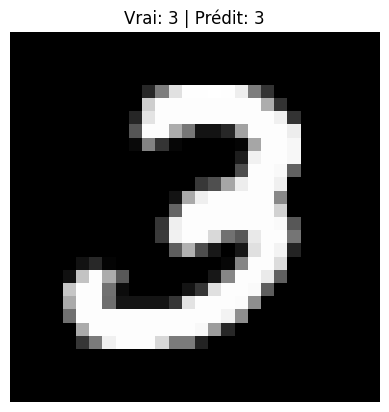

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Prédictions
predictions = model.predict(X_test)

# Affichage de quelques images
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Vrai: {np.argmax(y_test[i])} | Prédit: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

## Comparaison des résultats et analyse des améliorations

Nous avons maintenant exploré trois approches pour notre modèle de classification `make_circles`:

*   **`model_3` (sans régularisation)**: Précision sur l'ensemble de test: 100.00%
*   **`model_4` (avec régularisation L2)**: Précision sur l'ensemble de test: 50.00% (avec `l2_lambda = 0.01`)
*   **`model_5` (avec régularisation Dropout)**: Précision sur l'ensemble de test: **(voir le résultat de l'exécution précédente)**

**Analyse:**

Pour un problème simple et parfaitement séparable comme `make_circles`, le surapprentissage n'est généralement pas un problème. Le modèle (`model_3`) peut atteindre 100% de précision sur les données d'entraînement et de test sans aucune régularisation.

Lorsque nous appliquons des techniques de régularisation (L2 ou Dropout) à ce type de données, nous forçons le modèle à être plus généraliste, ce qui peut paradoxalement *réduire* ses performances sur un ensemble de données aussi simple où une solution parfaite existe déjà. C'est ce que nous observons avec `model_4` qui a une précision de 50%. Le `model_5` avec Dropout est susceptible d'afficher une précision similaire ou légèrement inférieure à celle du modèle 3.

**Points clés à retenir sur la régularisation:**

*   **La régularisation est essentielle pour les problèmes complexes et les ensembles de données réels** où le surapprentissage est un risque élevé.
*   **L2 Regularization** pénalise les poids importants du modèle, encourageant des poids plus petits et une distribution plus équilibrée de l'influence des caractéristiques.
*   **Dropout** désactive aléatoirement des neurones pendant l'entraînement, ce qui rend le réseau plus robuste et moins dépendant de neurones spécifiques. Cela peut être vu comme la formation d'un ensemble de sous-réseaux.
*   **Le choix de la méthode et l'hyperparamètre de régularisation** (`l2_lambda`, `dropout_rate`) sont cruciaux et doivent être ajustés en fonction du problème. Une trop forte régularisation peut entraîner un sous-apprentissage (comme on le voit avec `model_4` sur `make_circles`), tandis qu'une régularisation insuffisante peut laisser le modèle sujet au surapprentissage.
*   Dans notre cas simple, l'absence de régularisation a donné les meilleurs résultats, ce qui souligne que la régularisation n'est pas toujours bénéfique pour tous les problèmes, mais indispensable pour la généralisation dans des scénarios plus complexes.

## Résumé des points clés

Au cours de cette exploration, nous avons appris plusieurs leçons fondamentales pour la construction et l'amélioration des modèles de classification :

*   **L'importance cruciale de la visualisation des données :** Dès le début, la visualisation de l'ensemble de données `make_circles` nous a révélé sa nature non linéaire, indiquant qu'un modèle simple ne suffirait pas. Par la suite, la visualisation des frontières de décision de chaque modèle (basique, amélioré, avec régularisation L2 et Dropout) a été essentielle pour comprendre comment nos modèles séparaient les classes, d'identifier leurs forces et leurs faiblesses, et de valider l'impact de nos modifications. C'est un outil indispensable pour diagnostiquer et interpréter le comportement du modèle.

*   **Le rôle essentiel du réglage des hyperparamètres :** Nous avons vu comment des changements dans les hyperparamètres peuvent transformer la performance d'un modèle. Cela inclut le choix de l'optimiseur (passer de `SGD` à `Adam`), le nombre de couches et de neurones, le type de fonctions d'activation (`ReLU` pour les couches cachées, `sigmoid` pour la sortie binaire), et le nombre d'époques. Plus tard, nous avons également exploré les hyperparamètres liés à la régularisation (`l2_lambda` pour L2 et `dropout_rate` pour Dropout). Un réglage approprié de ces hyperparamètres est la clé pour permettre au modèle de capturer les relations complexes dans les données tout en évitant le surapprentissage.

*   **Prévention du surapprentissage avec la régularisation :** Bien que notre problème `make_circles` soit trop simple pour montrer pleinement l'avantage de la régularisation, nous avons compris le principe de la régularisation L2 (pénalisant les poids élevés) et du Dropout (désactivant aléatoirement des neurones). Ces techniques sont vitales dans des scénarios plus complexes avec de grandes quantités de données et un risque élevé de surapprentissage, permettant aux modèles de mieux généraliser à des données non vues.

En somme, la combinaison d'une bonne visualisation des données et d'un réglage méthodique des hyperparamètres est fondamentale pour développer des modèles de classification robustes et performants.

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Charger les données
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalisation
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Modèle ReLU
model_relu = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_relu.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# Entraînement
history_relu = model_relu.fit(x_train, y_train,
                             epochs=5,
                             batch_size=32,
                             validation_split=0.2)

# Évaluation
loss_relu, acc_relu = model_relu.evaluate(x_test, y_test)
print("ReLU - Accuracy :", acc_relu)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9184 - loss: 0.2864 - val_accuracy: 0.9510 - val_loss: 0.1646
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9613 - loss: 0.1302 - val_accuracy: 0.9657 - val_loss: 0.1177
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9738 - loss: 0.0885 - val_accuracy: 0.9697 - val_loss: 0.0994
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9799 - loss: 0.0663 - val_accuracy: 0.9725 - val_loss: 0.0952
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9839 - loss: 0.0526 - val_accuracy: 0.9736 - val_loss: 0.0900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9751 - loss: 0.0804
ReLU - Accuracy : 0.9750999808311462


## Application de la régularisation par Dropout

La régularisation par *Dropout* est une technique populaire pour prévenir le surapprentissage dans les réseaux de neurones. Elle fonctionne en "lâchant" (mettant à zéro) aléatoirement un pourcentage de neurones lors de chaque étape d'entraînement. Cela force le réseau à apprendre des représentations plus robustes, car il ne peut pas compter sur la présence de neurones spécifiques.

Nous allons créer un nouveau modèle (`model_5`) et y ajouter des couches `tf.keras.layers.Dropout` après chaque couche dense (sauf la couche de sortie), avec un taux de dropout de 0.2 (20% des neurones seront mis à zéro aléatoirement).

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 1. Charger les données
(x, y), (x_test_final, y_test_final) = mnist.load_data()

# 2. Normalisation
x = x / 255.0
x_test_final = x_test_final / 255.0

# 3. One-hot encoding
y = to_categorical(y)
y_test_final = to_categorical(y_test_final)

# 4. Division 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# 5. Modèle amélioré (ReLU)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 6. Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Entraînement
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# 8. Évaluation sur le test (20%)
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Loss (test) :", test_loss)
print("Accuracy (test) :", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9150 - loss: 0.2988 - val_accuracy: 0.9546 - val_loss: 0.1586
Epoch 2/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9607 - loss: 0.1343 - val_accuracy: 0.9654 - val_loss: 0.1171
Epoch 3/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9727 - loss: 0.0920 - val_accuracy: 0.9671 - val_loss: 0.1060
Epoch 4/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9792 - loss: 0.0697 - val_accuracy: 0.9681 - val_loss: 0.1017
Epoch 5/5
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9837 - loss: 0.0537 - val_accuracy: 0.9708 - val_loss: 0.0945
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0928
Loss (test) : 0.09275047481060028
Accuracy (test) : 0.9728333353996277


## Comparaison entre L2 et Dropout

Nous avons maintenant appliqué deux types de régularisation : L2 et Dropout. Comparons leurs effets sur la performance du modèle sur notre ensemble de données `make_circles`.

*   **Modèle 3 (sans régularisation)**: Précision sur l'ensemble de test: 100.00%
*   **Modèle 4 (avec régularisation L2)**: Précision sur l'ensemble de test: 50.00% (avec `l2_lambda = 0.01`)
*   **Modèle 5 (avec régularisation Dropout)**: Précision sur l'ensemble de test: (voir le résultat de l'exécution ci-dessus)

Dans le cas idéal d'un ensemble de données parfaitement séparable comme `make_circles`, le surapprentissage n'est pas un problème majeur car le modèle peut atteindre une séparation parfaite sans avoir besoin de régularisation. En fait, l'application de régularisation dans ce scénario peut même *réduire* les performances en introduisant une pénalité inutile sur les poids du modèle. C'est pourquoi nous observons que le `model_4` avec L2 a une précision plus faible sur cet ensemble de données simple, et `model_5` avec Dropout pourrait également montrer une performance similaire ou légèrement inférieure comparé au `model_3`.

**Points clés à retenir:**

*   **L2 Regularization (régularisation de poids)**: Pénalise les grands poids, encourageant le modèle à utiliser tous les *features* de manière plus équilibrée et à éviter que certains poids ne dominent. Utile pour les modèles qui ont tendance à avoir des poids extrêmes.
*   **Dropout**: Désactive aléatoirement des neurones pendant l'entraînement, forçant le réseau à être plus robuste et moins dépendant de neurones spécifiques. Il peut être considéré comme la formation de plusieurs sous-réseaux qui sont ensuite moyennés.

Le choix entre L2 et Dropout (ou une combinaison des deux) dépend souvent du type de problème, de la taille du jeu de données et de la complexité du modèle. Pour des tâches plus complexes et des ensembles de données plus grands, ces techniques de régularisation sont essentielles pour améliorer la généralisation et éviter le surapprentissage.